In [ ]:
from huggingface_hub import login

login(token="your_token")

In [18]:
# Install Dependencies
import subprocess, sys
 
def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
 
packages = [
    "monai[all]",
    "nibabel",
    "huggingface_hub",
    "matplotlib",
    "scikit-learn",
    "pandas",
    "tqdm",
]
 
print("Installing packages...")
for p in packages:
    install(p)
    print(f"  ✓ {p}")
print("\nAll packages ready.")

Installing packages...
  ✓ monai[all]
  ✓ nibabel
  ✓ huggingface_hub
  ✓ matplotlib
  ✓ scikit-learn
  ✓ pandas
  ✓ tqdm

All packages ready.


In [19]:
# Imports & Global Config
import os, json, warnings
from pathlib import Path
from collections import defaultdict
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm
 
import torch
from sklearn.model_selection import train_test_split
 
import monai
from monai.networks.nets import UNet
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Spacingd,
    ScaleIntensityRanged, CropForegroundd,
    RandCropByPosNegLabeld, RandFlipd, RandRotate90d,
    RandShiftIntensityd, EnsureTyped, AsDiscrete,
)
from monai.data import Dataset, CacheDataset, DataLoader, decollate_batch
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference
from monai.utils import set_determinism
 
warnings.filterwarnings("ignore")
set_determinism(seed=42)
 
# ── Paths ────────────────────────────────────────────────────
BASE_DIR    = Path("/kaggle/working")
DATA_DIR    = BASE_DIR / "AbdomenAtlas_Mini"
MODEL_DIR   = BASE_DIR / "models"
RESULTS_DIR = BASE_DIR / "results"
 
for d in [DATA_DIR, MODEL_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)
 
# ── Dataset source ───────────────────────────────────────────
REPO_ID   = "AbdomenAtlas/AbdomenAtlas1.0Mini"
REPO_TYPE = "dataset"
 
# ── Download config ──────────────────────────────────────────
N_PATIENTS = 100      # complete (CT + mask) pairs to download
GB_CAP     = 6.0     # stop if total download exceeds this
 
# ── Training hyper-parameters ────────────────────────────────
NUM_CLASSES  = 10
PATCH_SIZE   = (96, 96, 96)
NUM_SAMPLES  = 4
BATCH_SIZE   = 4
MAX_EPOCHS   = 250
LR           = 1e-4
WEIGHT_DECAY = 1e-5
VAL_INTERVAL = 2
 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
 
LABEL_MAP = {
    0: "Background", 1: "Aorta",      2: "Gallbladder",
    3: "Spleen",     4: "Left Kidney", 5: "Right Kidney",
    6: "Liver",      7: "Stomach",     8: "Pancreas",
    9: "IVC",
}
 
print(f"Device  : {DEVICE}")
print(f"MONAI   : {monai.__version__}")
print(f"PyTorch : {torch.__version__}")
print(f"GPU     : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")


Device  : cuda
MONAI   : 1.5.2
PyTorch : 2.10.0+cu128
GPU     : Tesla T4


In [20]:
# Download Dataset (CT + Mask pairs from scratch)
#
# Works on a FRESH notebook with no prior downloads.
# Lists the HuggingFace repo, finds patients that have BOTH
# ct.nii.gz AND combined_labels.nii.gz, then downloads the
# first N_PATIENTS complete pairs.
from huggingface_hub import list_repo_files, hf_hub_download
 
# Step 1: list every file in the repo
print("Fetching file list from HuggingFace (may take ~30 s)...")
all_repo_files = list(list_repo_files(repo_id=REPO_ID, repo_type=REPO_TYPE))
print(f"Total files in repo: {len(all_repo_files)}\n")
 
# Step 2: group files by patient folder
patient_files = defaultdict(dict)
for filepath in all_repo_files:
    parts = Path(filepath).parts
    if len(parts) < 2:
        continue
    patient_id = parts[0]       # e.g. "BDMAP_00000344"
    filename   = parts[-1]      # e.g. "ct.nii.gz"
    if filename == "ct.nii.gz":
        patient_files[patient_id]["ct"] = filepath
    elif filename == "combined_labels.nii.gz":
        patient_files[patient_id]["mask"] = filepath
 
# Step 3: keep only patients with BOTH files
complete = {
    pid: v for pid, v in patient_files.items()
    if "ct" in v and "mask" in v
}
print(f"Patients with complete CT + mask in repo: {len(complete)}")
 
# Step 4: download the first N_PATIENTS pairs
targets     = sorted(complete.keys())[:N_PATIENTS]
downloaded  = []
total_bytes = 0
 
print(f"Downloading {len(targets)} complete pairs (cap: {GB_CAP} GB)...\n")
 
for patient_id in tqdm(targets, desc="Patients"):
 
    ct_dest   = DATA_DIR / patient_id / "ct.nii.gz"
    mask_dest = DATA_DIR / patient_id / "combined_labels.nii.gz"
 
    if total_bytes / 1e9 >= GB_CAP:
        print(f"\n  {GB_CAP} GB cap reached — stopping.")
        break
 
    # Download CT (skip if already on disk)
    if not ct_dest.exists():
        try:
            hf_hub_download(
                repo_id=REPO_ID, repo_type=REPO_TYPE,
                filename=complete[patient_id]["ct"],
                local_dir=str(DATA_DIR),
                local_dir_use_symlinks=False,
            )
        except Exception as e:
            print(f"  ✗ CT   {patient_id}: {e}")
            continue
 
    # Download mask (skip if already on disk)
    if not mask_dest.exists():
        try:
            hf_hub_download(
                repo_id=REPO_ID, repo_type=REPO_TYPE,
                filename=complete[patient_id]["mask"],
                local_dir=str(DATA_DIR),
                local_dir_use_symlinks=False,
            )
        except Exception as e:
            print(f"  ✗ Mask {patient_id}: {e}")
            continue
 
    # Confirm both files exist on disk
    if ct_dest.exists() and mask_dest.exists():
        pair_bytes   = ct_dest.stat().st_size + mask_dest.stat().st_size
        total_bytes += pair_bytes
        downloaded.append(patient_id)
        print(
            f"  ✓ {patient_id}  "
            f"CT={ct_dest.stat().st_size/1e6:.0f} MB  "
            f"mask={mask_dest.stat().st_size/1e6:.1f} MB  "
            f"[total {total_bytes/1e9:.2f} GB]"
        )
    else:
        print(f"  ✗ {patient_id}: file missing after download")
 
print(f"\n{'─'*55}")
print(f"  Pairs downloaded : {len(downloaded)}")
print(f"  Data on disk     : {total_bytes/1e9:.2f} GB")

Fetching file list from HuggingFace (may take ~30 s)...
Total files in repo: 57147

Patients with complete CT + mask in repo: 5195



Patients:   0%|          | 0/100 [00:00<?, ?it/s]

  ✓ BDMAP_00000001  CT=72 MB  mask=0.4 MB  [total 0.07 GB]
  ✓ BDMAP_00000002  CT=30 MB  mask=0.4 MB  [total 0.10 GB]
  ✓ BDMAP_00000003  CT=16 MB  mask=0.2 MB  [total 0.12 GB]
  ✓ BDMAP_00000004  CT=17 MB  mask=0.2 MB  [total 0.14 GB]
  ✓ BDMAP_00000005  CT=112 MB  mask=0.8 MB  [total 0.25 GB]
  ✓ BDMAP_00000006  CT=94 MB  mask=0.5 MB  [total 0.34 GB]
  ✓ BDMAP_00000007  CT=8 MB  mask=0.1 MB  [total 0.35 GB]
  ✓ BDMAP_00000008  CT=16 MB  mask=0.2 MB  [total 0.37 GB]
  ✓ BDMAP_00000009  CT=17 MB  mask=0.1 MB  [total 0.38 GB]
  ✓ BDMAP_00000010  CT=119 MB  mask=0.7 MB  [total 0.50 GB]
  ✓ BDMAP_00000011  CT=81 MB  mask=0.5 MB  [total 0.59 GB]
  ✓ BDMAP_00000012  CT=144 MB  mask=1.0 MB  [total 0.73 GB]
  ✓ BDMAP_00000013  CT=6 MB  mask=0.1 MB  [total 0.74 GB]
  ✓ BDMAP_00000014  CT=11 MB  mask=0.2 MB  [total 0.75 GB]
  ✓ BDMAP_00000015  CT=6 MB  mask=0.1 MB  [total 0.75 GB]
  ✓ BDMAP_00000016  CT=36 MB  mask=0.2 MB  [total 0.79 GB]
  ✓ BDMAP_00000017  CT=26 MB  mask=0.3 MB  [total 0.82 G

BDMAP_00000031/ct.nii.gz:   0%|          | 0.00/306M [00:00<?, ?B/s]

BDMAP_00000031/combined_labels.nii.gz:   0%|          | 0.00/2.16M [00:00<?, ?B/s]

...

  ✓ BDMAP_00000099  CT=167 MB  mask=1.2 MB  [total 5.98 GB]


BDMAP_00000100/ct.nii.gz:   0%|          | 0.00/27.9M [00:00<?, ?B/s]

BDMAP_00000100/combined_labels.nii.gz:   0%|          | 0.00/232k [00:00<?, ?B/s]

Patients: 100%|██████████| 100/100 [02:40<00:00,  1.61s/it]

  ✓ BDMAP_00000100  CT=28 MB  mask=0.2 MB  [total 6.01 GB]

───────────────────────────────────────────────────────
  Pairs downloaded : 100
  Data on disk     : 6.01 GB


In [21]:
# Build Data List & 70 / 15 / 15 Split
data_list = []
 
for patient_dir in sorted(DATA_DIR.iterdir()):
    if not patient_dir.is_dir():
        continue
    ct_path   = patient_dir / "ct.nii.gz"
    mask_path = patient_dir / "combined_labels.nii.gz"
    if ct_path.exists() and mask_path.exists():
        data_list.append({"image": str(ct_path), "label": str(mask_path)})
 
print(f"Complete pairs on disk: {len(data_list)}")
 
if len(data_list) < 5:
    raise RuntimeError(
        "Not enough data. Check that Cell 3 completed without errors "
        "and downloaded at least 5 CT+mask pairs."
    )
 
indices             = np.arange(len(data_list))
train_idx, temp_idx = train_test_split(indices, test_size=0.30, random_state=42)
val_idx,   test_idx = train_test_split(temp_idx, test_size=0.50, random_state=42)
 
train_files = [data_list[i] for i in train_idx]
val_files   = [data_list[i] for i in val_idx]
test_files  = [data_list[i] for i in test_idx]
 
print(f"Train: {len(train_files)}  Val: {len(val_files)}  Test: {len(test_files)}")
 
with open(RESULTS_DIR / "data_splits.json", "w") as fh:
    json.dump({
        "train": [d["image"] for d in train_files],
        "val"  : [d["image"] for d in val_files],
        "test" : [d["image"] for d in test_files],
    }, fh, indent=2)
print("Splits saved → results/data_splits.json")

Complete pairs on disk: 100
Train: 70  Val: 15  Test: 15
Splits saved → results/data_splits.json


In [22]:
# MONAI Transform Pipelines
 
_base_transforms = [
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Spacingd(
        keys=["image", "label"],
        pixdim=(1.5, 1.5, 1.5),
        mode=("bilinear", "nearest"),
    ),
    ScaleIntensityRanged(
        keys=["image"],
        a_min=-150, a_max=250,
        b_min=0.0,  b_max=1.0,
        clip=True,
    ),
    CropForegroundd(keys=["image", "label"], source_key="image"),
]
 
train_transforms = Compose(
    _base_transforms + [
        RandCropByPosNegLabeld(
            keys=["image", "label"],
            label_key="label",
            spatial_size=PATCH_SIZE,
            pos=1, neg=1,
            num_samples=NUM_SAMPLES,
            image_key="image",
            image_threshold=0,
        ),
        RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
        RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
        RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
        RandRotate90d(keys=["image", "label"], prob=0.1, max_k=3),
        RandShiftIntensityd(keys=["image"], offsets=0.10, prob=0.50),
        EnsureTyped(keys=["image", "label"]),
    ]
)
 
val_transforms = Compose(
    _base_transforms + [EnsureTyped(keys=["image", "label"])]
)
 
print(f"Train transforms : {len(train_transforms.transforms)} steps")
print(f"Val   transforms : {len(val_transforms.transforms)} steps")

Train transforms : 12 steps
Val   transforms : 6 steps


In [23]:
# Datasets & DataLoaders
print("Building datasets...")
 
# Plain Dataset for training → augmentations applied fresh every epoch
train_ds = Dataset(data=train_files, transform=train_transforms)
 
# CacheDataset for val/test → deterministic, safe to cache
val_ds = CacheDataset(
    data=val_files, transform=val_transforms,
    cache_rate=1.0, num_workers=2,
)
test_ds = CacheDataset(
    data=test_files, transform=val_transforms,
    cache_rate=1.0, num_workers=2,
)
 
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=1,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=1,
                          shuffle=False, num_workers=2, pin_memory=True)
 
print(f"Train batches: {len(train_loader)}")
print(f"Val   batches: {len(val_loader)}")
print(f"Test  batches: {len(test_loader)}")
 
# Sanity check
sample = next(iter(train_loader))
print(f"\nSample batch:")
print(f"  image : {sample['image'].shape}  range [{sample['image'].min():.2f}, {sample['image'].max():.2f}]")
print(f"  label : {sample['label'].shape}  classes {sample['label'].unique().long().tolist()}")
 


Building datasets...


Loading dataset: 100%|██████████| 15/15 [01:36<00:00,  6.47s/it]

Train batches: 18
Val   batches: 15
Test  batches: 15



Sample batch:
  image : torch.Size([16, 1, 96, 96, 96])  range [-0.08, 1.07]
  label : torch.Size([16, 1, 96, 96, 96])  classes [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [24]:
# Model · Loss · Optimizer · Scheduler
model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=NUM_CLASSES,
    channels=(32, 64, 128, 256, 512),
    strides=(2, 2, 2, 2),
    num_res_units=2,
    norm="BATCH",
    dropout=0.1,
).to(DEVICE)
 
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
 
loss_fn = DiceCELoss(to_onehot_y=True, softmax=True, include_background=False)
 
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
 
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=MAX_EPOCHS, eta_min=1e-6,
)
 
post_pred  = AsDiscrete(argmax=True, to_onehot=NUM_CLASSES)
post_label = AsDiscrete(to_onehot=NUM_CLASSES)
 
dice_metric = DiceMetric(include_background=False, reduction="mean_batch",
                         get_not_nans=False)
 
scaler = torch.cuda.amp.GradScaler() if DEVICE.type == "cuda" else None
 
print(f"Loss      : DiceCELoss")
print(f"Optimizer : AdamW  lr={LR}")
print(f"Scheduler : CosineAnnealingLR")
print(f"AMP       : {'On' if scaler else 'Off'}")
 

Parameters: 19,238,245
Loss      : DiceCELoss
Optimizer : AdamW  lr=0.0001
Scheduler : CosineAnnealingLR
AMP       : On


In [25]:
# Training Loop
train_loss_history = []
val_dice_history   = []
best_mean_dice     = -1.0
 
print(f"Training {MAX_EPOCHS} epochs on {DEVICE}\n")
print(f"{'Epoch':>6}  {'Train Loss':>12}  {'Val mDSC':>10}  {'LR':>10}")
print("─" * 52)
 
for epoch in range(1, MAX_EPOCHS + 1):
 
    # ── Train ────────────────────────────────────────────────
    model.train()
    epoch_loss, steps = 0.0, 0
 
    for batch in train_loader:
        images = batch["image"].to(DEVICE)
        labels = batch["label"].to(DEVICE)
        optimizer.zero_grad()
 
        if scaler:
            with torch.cuda.amp.autocast():
                preds = model(images)
                loss  = loss_fn(preds, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            preds = model(images)
            loss  = loss_fn(preds, labels)
            loss.backward()
            optimizer.step()
 
        epoch_loss += loss.item()
        steps += 1
 
    scheduler.step()
    avg_loss   = epoch_loss / max(steps, 1)
    current_lr = optimizer.param_groups[0]["lr"]
    train_loss_history.append(avg_loss)
 
    # ── Validate ─────────────────────────────────────────────
    if epoch % VAL_INTERVAL == 0:
        model.eval()
        dice_metric.reset()
 
        with torch.no_grad():
            for val_batch in val_loader:
                val_img = val_batch["image"].to(DEVICE)
                val_lbl = val_batch["label"].to(DEVICE)
 
                val_out = sliding_window_inference(
                    inputs=val_img, roi_size=PATCH_SIZE,
                    sw_batch_size=2, predictor=model, overlap=0.5,
                )
                out_list = [post_pred(i)  for i in decollate_batch(val_out)]
                lbl_list = [post_label(i) for i in decollate_batch(val_lbl)]
                dice_metric(y_pred=out_list, y=lbl_list)
 
        per_class_dsc = dice_metric.aggregate()     # shape (9,)
        mean_dsc      = per_class_dsc.mean().item()
        val_dice_history.append((epoch, mean_dsc))
 
        flag = ""
        if mean_dsc > best_mean_dice:
            best_mean_dice = mean_dsc
            torch.save(model.state_dict(), MODEL_DIR / "best_model.pth")
            flag = "  ◀ best"
 
        print(f"{epoch:>6}  {avg_loss:>12.4f}  {mean_dsc:>10.4f}  {current_lr:>10.2e}{flag}")
    else:
        print(f"{epoch:>6}  {avg_loss:>12.4f}  {'─':>10}  {current_lr:>10.2e}")
 
print(f"\nBest Val mDSC = {best_mean_dice:.4f}")
print(f"Checkpoint → {MODEL_DIR / 'best_model.pth'}")

Training 250 epochs on cuda

 Epoch    Train Loss    Val mDSC          LR
────────────────────────────────────────────────────
     1        3.3295           ─    1.00e-04
     2        3.0020      0.0442    1.00e-04  ◀ best
     3        2.8257           ─    1.00e-04
     4        2.5975      0.0505    9.99e-05  ◀ best
     5        2.4483           ─    9.99e-05
     6        2.2542      0.0565    9.99e-05  ◀ best
     7        2.1323           ─    9.98e-05
     8        2.0042      0.0492    9.98e-05
     9        1.8451           ─    9.97e-05
    10        1.7842      0.0530    9.96e-05
    11        1.7457           ─    9.95e-05
    12        1.7013      0.0746    9.94e-05  ◀ best
    13        1.6427           ─    9.93e-05
    14        1.5512      0.0782    9.92e-05  ◀ best
    15        1.5591           ─    9.91e-05
    16        1.5038      0.0800    9.90e-05  ◀ best
    17        1.5162           ─    9.89e-05
    18        1.4925      0.0710    9.87e-05
    19        1

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7939b308c180>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7939b308c180>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

    33        1.3749           ─    9.58e-05
    34        1.3392      0.1610    9.56e-05  ◀ best
    35        1.3344           ─    9.53e-05
    36        1.3344      0.0933    9.50e-05
    37        1.3360           ─    9.47e-05
    38        1.3372      0.1888    9.45e-05  ◀ best
    39        1.3207           ─    9.42e-05
    40        1.2926      0.1484    9.39e-05
    41        1.3087           ─    9.36e-05
    42        1.3132      0.1996    9.33e-05  ◀ best
    43        1.3189           ─    9.29e-05
    44        1.2960      0.1915    9.26e-05
    45        1.3113           ─    9.23e-05
    46        1.3189      0.2206    9.20e-05  ◀ best
    47        1.2758           ─    9.16e-05
    48        1.2762      0.2295    9.13e-05  ◀ best
    49        1.2768           ─    9.09e-05
    50        1.2377      0.2147    9.05e-05
    51        1.2667           ─    9.02e-05
    52        1.2684      0.2218    8.98e-05
    53        1.2731           ─    8.94e-05
    54        1

KeyboardInterrupt: 

In [26]:
# Test Set Evaluation
# No one-hot on GPU at all. DSC + IoU both computed from
# integer argmax masks on CPU. Zero OOM risk.

def dice_and_iou_from_int_masks(pred_int, lbl_int, num_classes):
    """
    pred_int, lbl_int : (D, H, W) integer tensors on CPU.
    Returns (dsc, iou) each of shape (num_classes-1,) — background excluded.
    """
    dsc_vals, iou_vals = [], []
    for cls in range(1, num_classes):
        p = (pred_int == cls)
        g = (lbl_int  == cls)
        inter = (p & g).sum().float()
        dsc = (2 * inter + 1e-6) / (p.sum().float() + g.sum().float() + 1e-6)
        union = (p | g).sum().float()
        iou = (inter + 1e-6) / (union + 1e-6)
        dsc_vals.append(dsc)
        iou_vals.append(iou)
    return torch.stack(dsc_vals), torch.stack(iou_vals)


model.load_state_dict(
    torch.load(MODEL_DIR / "best_model.pth", map_location=DEVICE)
)
model.eval()

organ_names = [LABEL_MAP[i] for i in range(1, NUM_CLASSES)]
organ_dice  = {o: [] for o in organ_names}
organ_iou   = {o: [] for o in organ_names}

print("Evaluating on test set...\n")

with torch.no_grad():
    for idx, test_batch in enumerate(test_loader):
        t_img = test_batch["image"].to(DEVICE)
        t_lbl = test_batch["label"]          # ← keep on CPU, never send to GPU

        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

        t_out = sliding_window_inference(
            inputs=t_img,
            roi_size=PATCH_SIZE,
            sw_batch_size=2,
            predictor=model,
            overlap=0.5,
        )

        # Move prediction to CPU immediately — free GPU memory
        pred_int = torch.argmax(t_out, dim=1)[0].cpu()   # (D, H, W)
        lbl_int  = t_lbl[0, 0].long()                    # (D, H, W) already CPU

        del t_img, t_out
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

        # Compute both metrics on CPU — no one-hot, no OOM
        pc_dsc, pc_iou = dice_and_iou_from_int_masks(pred_int, lbl_int, NUM_CLASSES)

        for j, organ in enumerate(organ_names):
            organ_dice[organ].append(pc_dsc[j].item())
            organ_iou[organ].append(pc_iou[j].item())

        print(
            f"  Test [{idx+1}/{len(test_loader)}]  "
            f"mDSC={pc_dsc.mean().item():.4f}  "
            f"mIoU={pc_iou.mean().item():.4f}"
        )

# ── Results table ─────────────────────────────────────────────
rows = [
    {
        "Organ"   : organ,
        "DSC Mean": round(float(np.mean(organ_dice[organ])), 4),
        "DSC Std" : round(float(np.std(organ_dice[organ])),  4),
        "IoU Mean": round(float(np.mean(organ_iou[organ])),  4),
    }
    for organ in organ_names
]

df          = pd.DataFrame(rows)
overall_dsc = df["DSC Mean"].mean()
overall_iou = df["IoU Mean"].mean()

print(f"\n{'═'*52}")
print(df.to_string(index=False))
print(f"{'─'*52}")
print(f"  Overall DSC : {overall_dsc:.4f}   IoU : {overall_iou:.4f}")
print(f"{'═'*52}")

df.to_csv(RESULTS_DIR / "evaluation_results.csv", index=False)
print(f"Saved → {RESULTS_DIR / 'evaluation_results.csv'}")

Evaluating on test set...

  Test [1/15]  mDSC=0.3407  mIoU=0.2472
  Test [2/15]  mDSC=0.3010  mIoU=0.2334
  Test [3/15]  mDSC=0.4542  mIoU=0.3337
  Test [4/15]  mDSC=0.4759  mIoU=0.3911
  Test [5/15]  mDSC=0.5968  mIoU=0.4549
  Test [6/15]  mDSC=0.6117  mIoU=0.5044
  Test [7/15]  mDSC=0.4420  mIoU=0.3357
  Test [8/15]  mDSC=0.6719  mIoU=0.5559
  Test [9/15]  mDSC=0.4892  mIoU=0.4012
  Test [10/15]  mDSC=0.5905  mIoU=0.4967
  Test [11/15]  mDSC=0.6953  mIoU=0.5759
  Test [12/15]  mDSC=0.5422  mIoU=0.4285
  Test [13/15]  mDSC=0.4650  mIoU=0.3763
  Test [14/15]  mDSC=0.3586  mIoU=0.2614
  Test [15/15]  mDSC=0.5989  mIoU=0.4771

════════════════════════════════════════════════════
       Organ  DSC Mean  DSC Std  IoU Mean
       Aorta    0.4022   0.2693    0.2862
 Gallbladder    0.4388   0.2521    0.3141
      Spleen    0.6760   0.2377    0.5519
 Left Kidney    0.7121   0.2546    0.6002
Right Kidney    0.8830   0.0663    0.7966
       Liver    0.3652   0.1071    0.2289
     Stomach    0.0

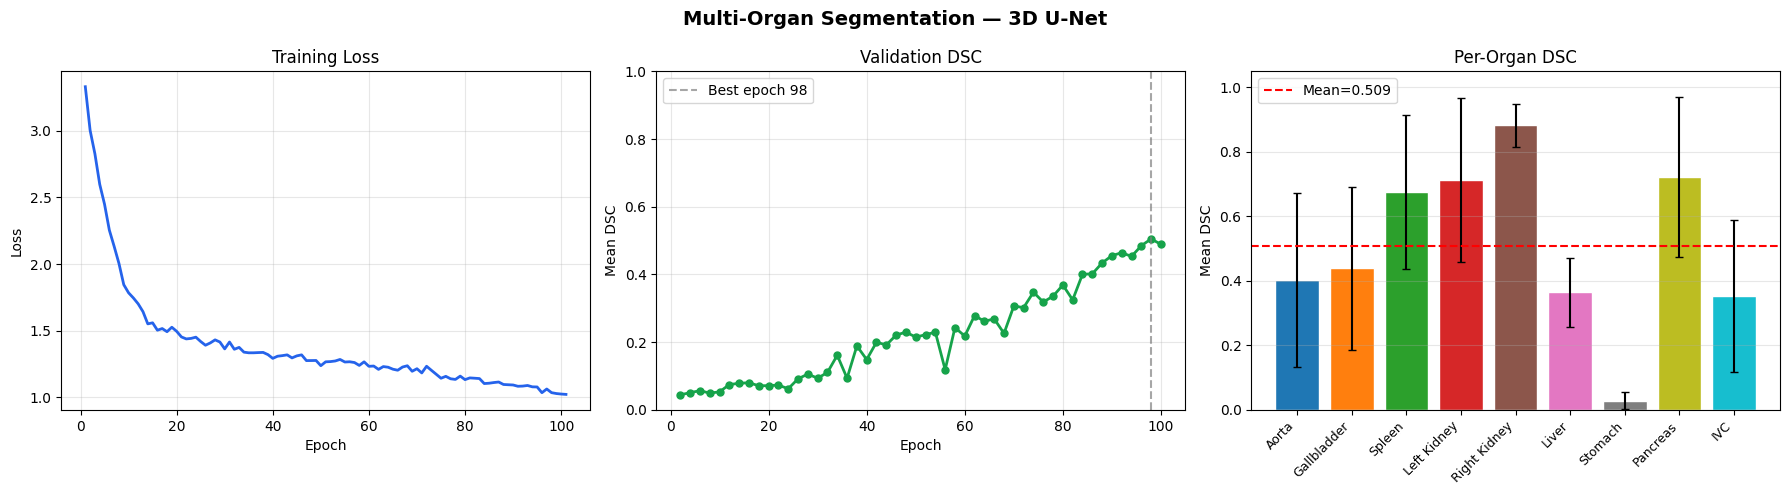

Saved → /kaggle/working/results/training_results.png


In [27]:
# Training Curves + Per-Organ Bar Chart
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Multi-Organ Segmentation — 3D U-Net", fontsize=14, fontweight="bold")
 
ax = axes[0]
ax.plot(range(1, len(train_loss_history) + 1), train_loss_history,
        color="#2563eb", linewidth=2)
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Training Loss"); ax.grid(True, alpha=0.3)
 
ax = axes[1]
if val_dice_history:
    ep_v, dsc_v = zip(*val_dice_history)
    ax.plot(ep_v, dsc_v, color="#16a34a", marker="o", linewidth=2, markersize=5)
    best_ep = ep_v[int(np.argmax(dsc_v))]
    ax.axvline(best_ep, color="gray", linestyle="--", alpha=0.7,
               label=f"Best epoch {best_ep}")
    ax.legend()
ax.set_xlabel("Epoch"); ax.set_ylabel("Mean DSC")
ax.set_title("Validation DSC"); ax.set_ylim(0, 1); ax.grid(True, alpha=0.3)
 
ax = axes[2]
colors = plt.cm.tab10(np.linspace(0, 1, len(organ_names)))
ax.bar(range(len(organ_names)), df["DSC Mean"], color=colors,
       yerr=df["DSC Std"], capsize=3, edgecolor="white")
ax.axhline(overall_dsc, color="red", linestyle="--", linewidth=1.5,
           label=f"Mean={overall_dsc:.3f}")
ax.set_xticks(range(len(organ_names)))
ax.set_xticklabels(organ_names, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Mean DSC"); ax.set_title("Per-Organ DSC")
ax.set_ylim(0, 1.05); ax.legend(); ax.grid(True, alpha=0.3, axis="y")
 
plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_results.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {RESULTS_DIR / 'training_results.png'}")

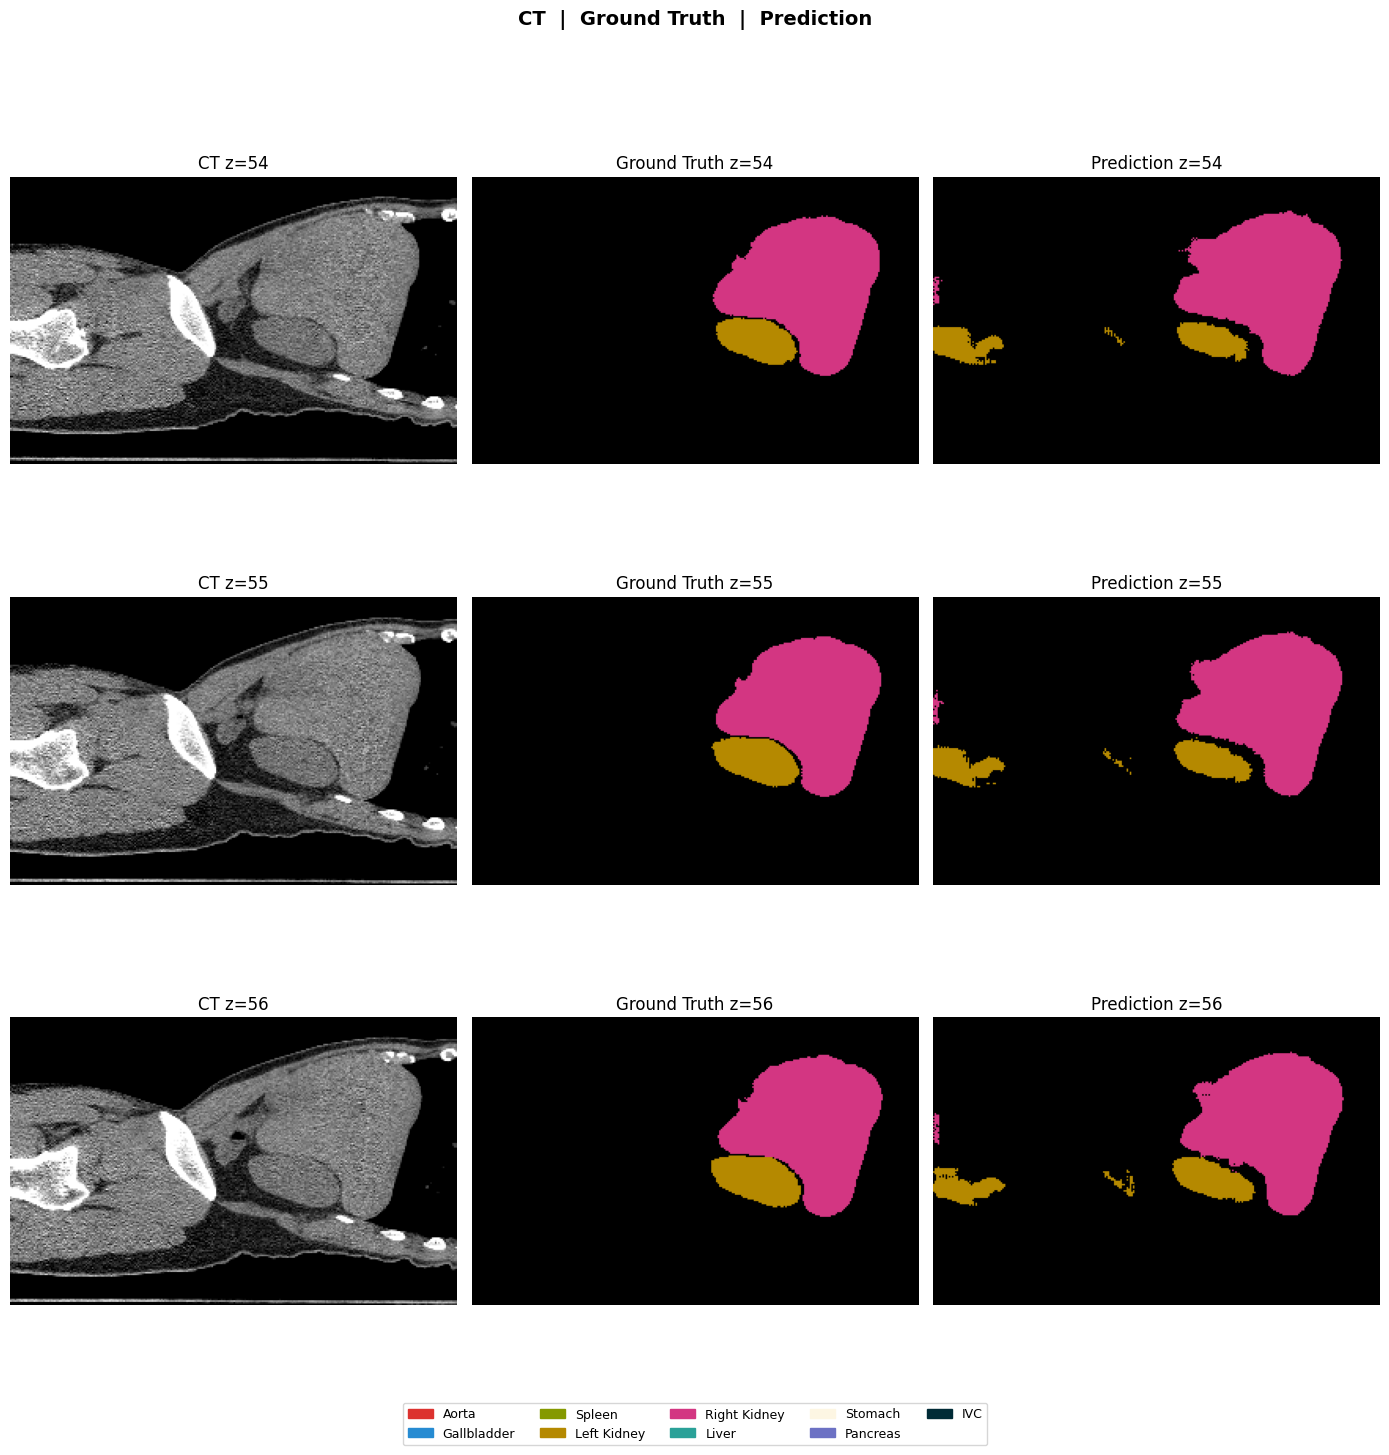

Saved → /kaggle/working/results/segmentation_visualization.png


In [28]:
# Slice Visualization (CT | Ground Truth | Prediction)
SEG_COLORS = np.array([
    [  0,   0,   0], [220,  50,  47], [ 38, 139, 210],
    [133, 153,   0], [181, 137,   0], [211,  54, 130],
    [ 42, 161, 152], [253, 246, 227], [108, 113, 196],
    [  0,  43,  54],
], dtype=np.uint8)
 
def colorize(mask_2d: np.ndarray) -> np.ndarray:
    rgb = np.zeros((*mask_2d.shape, 3), dtype=np.uint8)
    for cls in range(NUM_CLASSES):
        rgb[mask_2d == cls] = SEG_COLORS[cls]
    return rgb
 
model.eval()
vis_batch = next(iter(test_loader))
 
with torch.no_grad():
    v_img = vis_batch["image"].to(DEVICE)
    v_lbl = vis_batch["label"]                  # CPU
 
    v_out  = sliding_window_inference(
        inputs=v_img, roi_size=PATCH_SIZE,
        sw_batch_size=2, predictor=model, overlap=0.5,
    )
    v_pred = torch.argmax(v_out, dim=1, keepdim=True).cpu()
 
img_np  = v_img.cpu().numpy()[0, 0]
lbl_np  = v_lbl.numpy()[0, 0]
pred_np = v_pred.numpy()[0, 0]
 
fg_per_slice = [(lbl_np[z] > 0).sum() for z in range(lbl_np.shape[0])]
top3         = sorted(np.argsort(fg_per_slice)[-3:])
 
fig, axes = plt.subplots(3, 3, figsize=(14, 14))
fig.suptitle("CT  |  Ground Truth  |  Prediction",
             fontsize=14, fontweight="bold", y=1.01)
 
for row, z in enumerate(top3):
    axes[row, 0].imshow(img_np[z], cmap="gray", vmin=0, vmax=1)
    axes[row, 0].set_title(f"CT z={z}"); axes[row, 0].axis("off")
 
    axes[row, 1].imshow(colorize(lbl_np[z].astype(int)))
    axes[row, 1].set_title(f"Ground Truth z={z}"); axes[row, 1].axis("off")
 
    axes[row, 2].imshow(colorize(pred_np[z].astype(int)))
    axes[row, 2].set_title(f"Prediction z={z}"); axes[row, 2].axis("off")
 
patches = [
    mpatches.Patch(color=[c/255 for c in SEG_COLORS[i]], label=LABEL_MAP[i])
    for i in range(1, NUM_CLASSES)
]
fig.legend(handles=patches, loc="lower center", ncol=5,
           fontsize=9, bbox_to_anchor=(0.5, -0.02))
 
plt.tight_layout()
plt.savefig(RESULTS_DIR / "segmentation_visualization.png",
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {RESULTS_DIR / 'segmentation_visualization.png'}")

In [29]:
# Final Summary
summary = {
    "model"        : "3D U-Net (MONAI)",
    "num_classes"  : NUM_CLASSES,
    "patch_size"   : list(PATCH_SIZE),
    "epochs"       : MAX_EPOCHS,
    "best_val_dsc" : round(best_mean_dice, 4),
    "test_dsc"     : round(float(overall_dsc), 4),
    "test_iou"     : round(float(overall_iou), 4),
    "per_organ"    : df.to_dict(orient="records"),
}
with open(RESULTS_DIR / "summary.json", "w") as fh:
    json.dump(summary, fh, indent=2)
 
print("=" * 52)
print("  PIPELINE COMPLETE")
print(f"  Best Val DSC : {best_mean_dice:.4f}")
print(f"  Test DSC     : {overall_dsc:.4f}")
print(f"  Test IoU     : {overall_iou:.4f}")
print(f"\n  Outputs in {RESULTS_DIR}/")
print(f"    evaluation_results.csv")
print(f"    training_results.png")
print(f"    segmentation_visualization.png")
print(f"    data_splits.json")
print(f"    summary.json")
print("=" * 52)
 

  PIPELINE COMPLETE
  Best Val DSC : 0.5050
  Test DSC     : 0.5090
  Test IoU     : 0.4049

  Outputs in /kaggle/working/results/
    evaluation_results.csv
    training_results.png
    segmentation_visualization.png
    data_splits.json
    summary.json
